In [1]:

# Import necessary libraries
import pandas as pd
import numpy as np


In [2]:

# Load the dataset
file_path = "dataset_traffic_accident_prediction1.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)
df.head()


Dataset Loaded Successfully
Dataset Shape: (840, 14)


,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0


In [3]:

# Check missing values in each column
print("Missing Values Before Treatment:")
print(df.isnull().sum())


Missing Values Before Treatment:
Weather                 42
Road_Type               42
Time_of_Day             42
Traffic_Density         42
Speed_Limit             42
Number_of_Vehicles      42
Driver_Alcohol          42
Accident_Severity       42
Road_Condition          42
Vehicle_Type            42
Driver_Age              42
Driver_Experience       42
Road_Light_Condition    42
Accident                42
dtype: int64


In [4]:

# Impute numerical columns using median
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("Numerical Missing Values Imputed with Median")


Numerical Missing Values Imputed with Median


/tmp/ipykernel_8782/218947674.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [5]:

# Impute categorical columns using mode
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Categorical Missing Values Imputed with Mode")


Categorical Missing Values Imputed with Mode


/tmp/ipykernel_8782/916873008.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [6]:

# Verify missing values after imputation
print("Missing Values After Imputation:")
print(df.isnull().sum())


Missing Values After Imputation:
Weather                 0
Road_Type               0
Time_of_Day             0
Traffic_Density         0
Speed_Limit             0
Number_of_Vehicles      0
Driver_Alcohol          0
Accident_Severity       0
Road_Condition          0
Vehicle_Type            0
Driver_Age              0
Driver_Experience       0
Road_Light_Condition    0
Accident                0
dtype: int64


In [7]:

# Convert target to integer and perform one-hot encoding
df["Accident"] = df["Accident"].astype(int)

categorical_cols = df.select_dtypes(include=["object"]).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Final Dataset Shape After Encoding:", df_encoded.shape)
print(df_encoded.head())


Final Dataset Shape After Encoding: (840, 27)
   Traffic_Density  Speed_Limit  Number_of_Vehicles  Driver_Alcohol  \
0              1.0        100.0                 5.0             0.0   
1              1.0        120.0                 3.0             0.0   
2              1.0         60.0                 4.0             0.0   
3              2.0         60.0                 3.0             0.0   
4              1.0        195.0                11.0             0.0   

   Driver_Age  Driver_Experience  Accident  Weather_Foggy  Weather_Rainy  \
0        51.0               48.0         0          False           True   
1        49.0               43.0         0          False          False   
2        54.0               52.0         0          False           True   
3        34.0               31.0         0          False          False   
4        62.0               55.0         1          False           True   

   Weather_Snowy  ...  Accident_Severity_Low  Accident_Severity_Modera

In [8]:

# Descriptive statistics for numerical columns
# This gives count, mean, std, min, quartiles, and max for numeric features
print("Descriptive Statistics (Numerical Columns):")
print(df.describe())


Descriptive Statistics (Numerical Columns):
       Traffic_Density  Speed_Limit  Number_of_Vehicles  Driver_Alcohol  \
count       840.000000   840.000000          840.000000      840.000000   
mean          1.001190    70.497619            3.272619        0.152381   
std           0.764996    31.332695            1.967123        0.359604   
min           0.000000    30.000000            1.000000        0.000000   
25%           0.000000    50.000000            2.000000        0.000000   
50%           1.000000    60.000000            3.000000        0.000000   
75%           2.000000    80.000000            4.000000        0.000000   
max           2.000000   213.000000           14.000000        1.000000   

       Driver_Age  Driver_Experience    Accident  
count  840.000000         840.000000  840.000000  
mean    43.246429          38.982143    0.284524  
std     14.746406          14.886008    0.451456  
min     18.000000           9.000000    0.000000  
25%     31.000000        

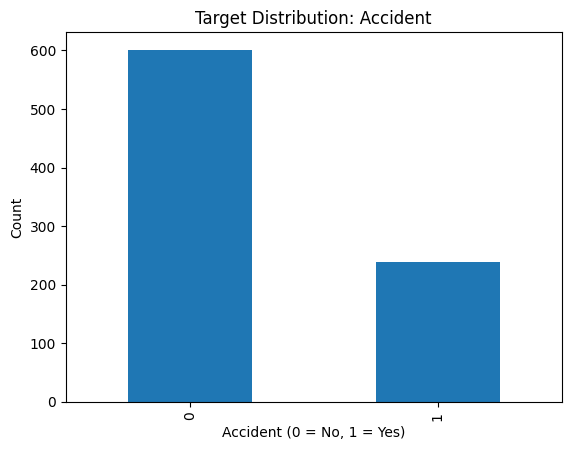

In [9]:

# Plot 1: Target variable distribution (Accident)
# Shows how many samples belong to class 0 and class 1
import matplotlib.pyplot as plt

plt.figure()
df["Accident"].value_counts().plot(kind="bar")
plt.title("Target Distribution: Accident")
plt.xlabel("Accident (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


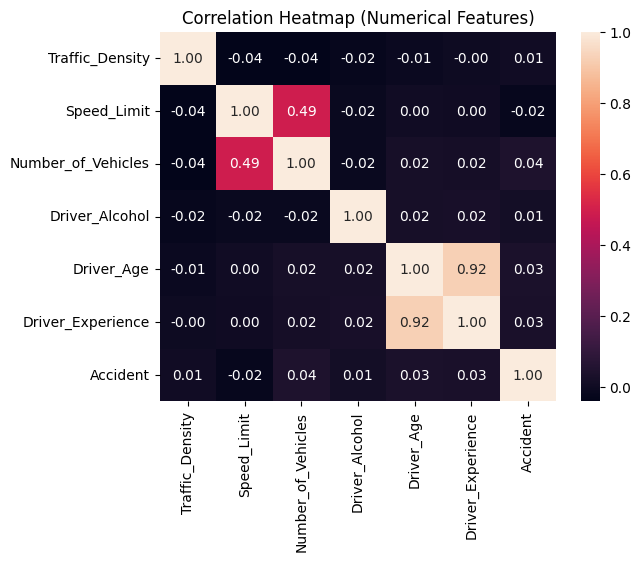

In [10]:

# Plot 3: Correlation Heatmap with Annotation
# Shows correlation values inside each cell

import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df.select_dtypes(include=["int64", "float64"]).corr()

plt.figure()
sns.heatmap(corr, annot=True, fmt=".2f")

plt.title("Correlation Heatmap (Numerical Features)")
plt.show()



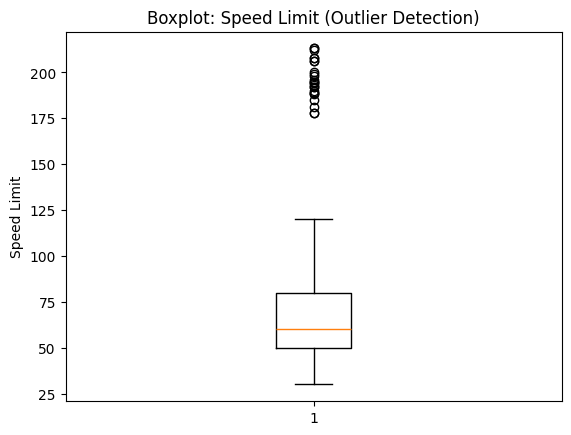

In [11]:

# Plot 2: Boxplot for outlier detection (Speed_Limit)
# Helps visually identify extreme values in Speed_Limit
plt.figure()
plt.boxplot(df["Speed_Limit"])
plt.title("Boxplot: Speed Limit (Outlier Detection)")
plt.ylabel("Speed Limit")
plt.show()


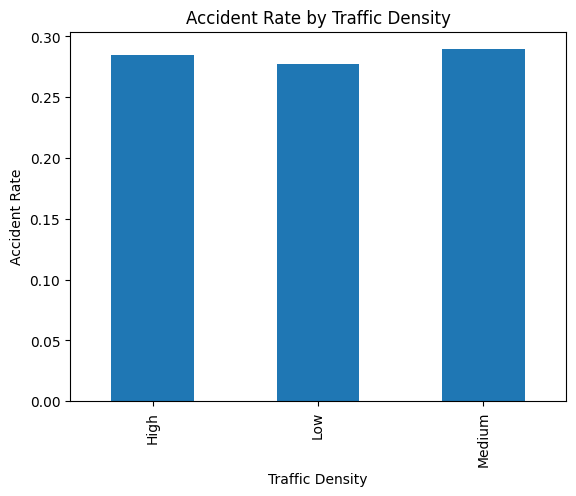

In [12]:

# Plot: Accident rate by Traffic Density (with meaningful labels)

# Create mapping for traffic density levels
density_map = {
    0: "Low",
    1: "Medium",
    2: "High"
}

# Create a temporary labeled column
df["Traffic_Density_Label"] = df["Traffic_Density"].map(density_map)

plt.figure()
df.groupby("Traffic_Density_Label")["Accident"].mean().plot(kind="bar")

plt.title("Accident Rate by Traffic Density")
plt.xlabel("Traffic Density")
plt.ylabel("Accident Rate")
plt.show()




/tmp/ipykernel_8782/2058658464.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Accident"].mean().plot(kind="bar")


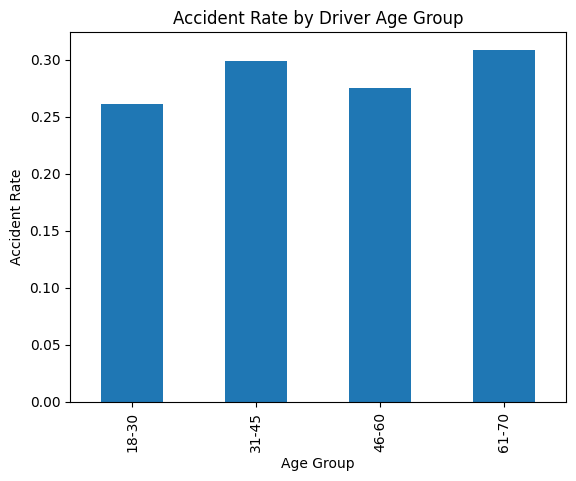

In [13]:

# Plot 5: Accident rate by Driver Age Group
# Creates age bins and compares accident rate across age groups
df["Age_Group"] = pd.cut(
    df["Driver_Age"],
    bins=[18, 30, 45, 60, 70],
    labels=["18-30", "31-45", "46-60", "61-70"],
    include_lowest=True
)

plt.figure()
df.groupby("Age_Group")["Accident"].mean().plot(kind="bar")
plt.title("Accident Rate by Driver Age Group")
plt.xlabel("Age Group")
plt.ylabel("Accident Rate")
plt.show()


In [15]:
# drop rows where target is missing
df = df.dropna(subset=["Accident"])

# convert target to integer
df["Accident"] = df["Accident"].astype(int)

# drop leakage column if it still exists
if "Accident_Severity" in df.columns:
    df = df.drop(columns=["Accident_Severity"])

# one-hot encode both object and category columns
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# convert boolean columns to integer
bool_cols = df_encoded.select_dtypes(include=["bool"]).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(df_encoded.dtypes)
print(df_encoded.head())

Traffic_Density                      float64
Speed_Limit                          float64
Number_of_Vehicles                   float64
Driver_Alcohol                       float64
Driver_Age                           float64
Driver_Experience                    float64
Accident                               int64
Weather_Foggy                          int64
Weather_Rainy                          int64
Weather_Snowy                          int64
Weather_Stormy                         int64
Road_Type_Highway                      int64
Road_Type_Mountain Road                int64
Road_Type_Rural Road                   int64
Time_of_Day_Evening                    int64
Time_of_Day_Morning                    int64
Time_of_Day_Night                      int64
Road_Condition_Icy                     int64
Road_Condition_Under Construction      int64
Road_Condition_Wet                     int64
Vehicle_Type_Car                       int64
Vehicle_Type_Motorcycle                int64
Vehicle_Ty

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# features and target
X = df_encoded.drop(columns=["Accident"])
y = df_encoded["Accident"]

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Scaling completed successfully
X_train shape: (672, 29)
X_test shape: (168, 29)


In [17]:
# convert scaled arrays back to dataframe
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(X_train_scaled.head())

     Traffic_Density  Speed_Limit  Number_of_Vehicles  Driver_Alcohol  \
536        -1.289574     0.943625           -0.163109        2.363945   
331         0.023447    -1.254460           -1.137411        2.363945   
362        -1.289574    -0.626436           -0.650260       -0.423022   
468         0.023447     0.315601            0.324042       -0.423022   
426         0.023447    -0.312423            0.324042       -0.423022   

     Driver_Age  Driver_Experience  Weather_Foggy  Weather_Rainy  \
536    1.644364           1.732826       -0.38309       1.628550   
331   -0.482904          -0.530390       -0.38309      -0.614043   
362    0.546419           0.841256       -0.38309      -0.614043   
468    1.301256           1.115585       -0.38309      -0.614043   
426    0.615041           0.361180       -0.38309       1.628550   

     Weather_Snowy  Weather_Stormy  ...  Vehicle_Type_Car  \
536      -0.335534        -0.23085  ...          0.568185   
331      -0.335534        -0.2

In [19]:
# handle class imbalance using SMOTE

from imblearn.over_sampling import SMOTE

# create SMOTE object
smote = SMOTE(random_state=42)

# apply SMOTE only on training data
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# check new class distribution
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Accident
0    484
1    188
Name: count, dtype: int64

After SMOTE:
Accident
0    484
1    484
Name: count, dtype: int64


In [20]:
# Random Forest model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# create model
rf_model = RandomForestClassifier(random_state=42)

# train model on SMOTE data
rf_model.fit(X_train_smote, y_train_smote)

# predict on test data
y_pred_rf = rf_model.predict(X_test_scaled)

# model evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.6964285714285714

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.94      0.81       117
           1       0.50      0.14      0.22        51

    accuracy                           0.70       168
   macro avg       0.61      0.54      0.51       168
weighted avg       0.65      0.70      0.63       168


Confusion Matrix:
[[110   7]
 [ 44   7]]


In [21]:
# XGBoost model

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# create model
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

# train model on SMOTE data
xgb_model.fit(X_train_smote, y_train_smote)

# predict on test data
y_pred_xgb = xgb_model.predict(X_test_scaled)

# model evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 0.6904761904761905

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.88      0.80       117
           1       0.48      0.25      0.33        51

    accuracy                           0.69       168
   macro avg       0.61      0.57      0.57       168
weighted avg       0.65      0.69      0.66       168


Confusion Matrix:
[[103  14]
 [ 38  13]]


In [22]:
# Artificial Neural Network model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# create model
ann_model = Sequential()

# add layers
ann_model.add(Dense(32, activation='relu', input_shape=(X_train_smote.shape[1],)))
ann_model.add(Dense(16, activation='relu'))
ann_model.add(Dense(1, activation='sigmoid'))

# compile model
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# train model on SMOTE data
ann_model.fit(
    X_train_smote,
    y_train_smote,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# predict probabilities
y_pred_ann = ann_model.predict(X_test_scaled)

# convert probabilities into class labels
y_pred_ann = (y_pred_ann > 0.5).astype(int)

# model evaluation
print("ANN Accuracy:", accuracy_score(y_test, y_pred_ann))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ann))

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5129 - loss: 0.7048 - val_accuracy: 0.0979 - val_loss: 0.9057
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6111 - loss: 0.6516 - val_accuracy: 0.0464 - val_loss: 0.9410
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6230 - loss: 0.6355 - val_accuracy: 0.0670 - val_loss: 0.9234
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6553 - loss: 0.5954 - val_accuracy: 0.1340 - val_loss: 0.8967
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6798 - loss: 0.5815 - val_accuracy: 0.1856 - val_loss: 0.8886
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7026 - loss: 0.5627 - val_accuracy: 0.2835 - val_loss: 0.8420
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7298 - loss: 0.5411 - val_accuracy: 0.3093 - val_loss: 0.8434
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7429 - loss: 0.5439 - val_accuracy: 0.3247 - val_loss: 0.8320
Epo

In [23]:
# compare all models

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "ANN"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_ann)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_ann)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_ann)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_ann)
    ]
})

print(results)

           Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest  0.696429   0.500000  0.137255  0.215385
1        XGBoost  0.690476   0.481481  0.254902  0.333333
2            ANN  0.678571   0.451613  0.274510  0.341463


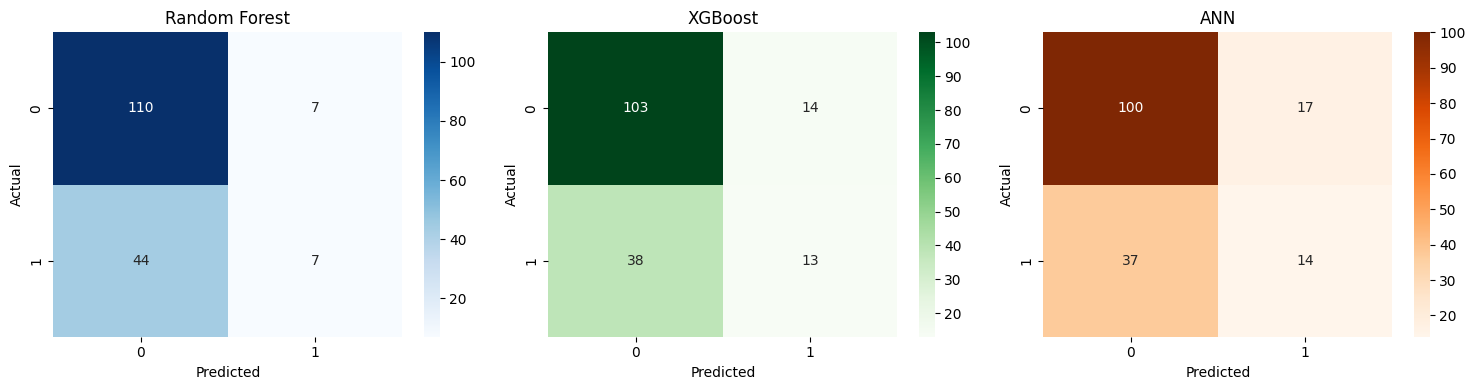

In [24]:
# plot confusion matrix for all models

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(15,4))

# Random Forest
plt.subplot(1,3,1)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# XGBoost
plt.subplot(1,3,2)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# ANN
plt.subplot(1,3,3)
cm_ann = confusion_matrix(y_test, y_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Oranges')
plt.title("ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


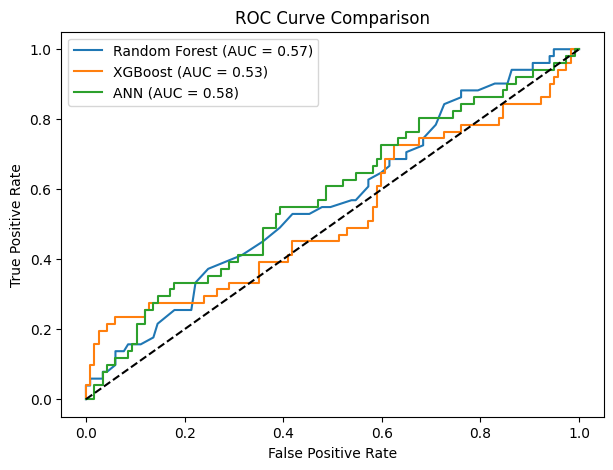

In [25]:
# ROC curve for all models

from sklearn.metrics import roc_curve, roc_auc_score

# predicted probabilities
rf_probs = rf_model.predict_proba(X_test_scaled)[:,1]
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:,1]
ann_probs = ann_model.predict(X_test_scaled).ravel()

# calculate ROC values
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
fpr_ann, tpr_ann, _ = roc_curve(y_test, ann_probs)

# calculate AUC scores
auc_rf = roc_auc_score(y_test, rf_probs)
auc_xgb = roc_auc_score(y_test, xgb_probs)
auc_ann = roc_auc_score(y_test, ann_probs)

# plot curves
plt.figure(figsize=(7,5))

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.2f})")
plt.plot(fpr_ann, tpr_ann, label=f"ANN (AUC = {auc_ann:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [26]:
# hyperparameter tuning for Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# parameter grid
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# base model
rf = RandomForestClassifier(random_state=42)

# grid search
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# train grid search
rf_grid.fit(X_train_smote, y_train_smote)

# best parameters
print("Best Parameters for Random Forest:")
print(rf_grid.best_params_)

# best model
best_rf_model = rf_grid.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters for Random Forest:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [27]:
# evaluate tuned Random Forest model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_best_rf = best_rf_model.predict(X_test_scaled)

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))

Tuned Random Forest Accuracy: 0.6785714285714286

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.92      0.80       117
           1       0.40      0.12      0.18        51

    accuracy                           0.68       168
   macro avg       0.55      0.52      0.49       168
weighted avg       0.61      0.68      0.61       168


Confusion Matrix:
[[108   9]
 [ 45   6]]


In [28]:
# hyperparameter tuning for XGBoost

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# parameter grid
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

# base model
xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

# grid search
xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# train grid search
xgb_grid.fit(X_train_smote, y_train_smote)

# best parameters
print("Best Parameters for XGBoost:")
print(xgb_grid.best_params_)

# best model
best_xgb_model = xgb_grid.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters for XGBoost:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [29]:
# evaluate tuned XGBoost model

y_pred_best_xgb = best_xgb_model.predict(X_test_scaled)

print("Tuned XGBoost Accuracy:", accuracy_score(y_test, y_pred_best_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_xgb))

Tuned XGBoost Accuracy: 0.6428571428571429

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.85      0.77       117
           1       0.33      0.18      0.23        51

    accuracy                           0.64       168
   macro avg       0.52      0.51      0.50       168
weighted avg       0.59      0.64      0.60       168


Confusion Matrix:
[[99 18]
 [42  9]]


In [31]:
# ANN hyperparameter tuning (manual)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score

best_accuracy = 0
best_params = None
best_model = None

# parameters to test
neurons_list = [16, 32]
epochs_list = [20, 30]
batch_sizes = [16, 32]

for neurons in neurons_list:
    for epochs in epochs_list:
        for batch in batch_sizes:

            # build model
            model = Sequential()
            model.add(Dense(neurons, activation='relu', input_shape=(X_train_smote.shape[1],)))
            model.add(Dense(neurons//2, activation='relu'))
            model.add(Dense(1, activation='sigmoid'))

            # compile model
            model.compile(
                optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy']
            )

            # train model
            model.fit(
                X_train_smote,
                y_train_smote,
                epochs=epochs,
                batch_size=batch,
                validation_split=0.2,
                verbose=0
            )

            # evaluate model
            y_pred = model.predict(X_test_scaled)
            y_pred = (y_pred > 0.5).astype(int)

            acc = accuracy_score(y_test, y_pred)

            print(f"neurons={neurons}, epochs={epochs}, batch={batch} → accuracy={acc:.4f}")

            # store best model
            if acc > best_accuracy:
                best_accuracy = acc
                best_params = (neurons, epochs, batch)
                best_model = model

print("\nBest ANN Parameters:", best_params)
print("Best ANN Accuracy:", best_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
neurons=16, epochs=20, batch=16 → accuracy=0.6369


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
neurons=16, epochs=20, batch=32 → accuracy=0.6429


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
neurons=32, epochs=20, batch=32 → accuracy=0.6131


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
neurons=32, epochs=30, batch=16 → accuracy=0.6131


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
neurons=32, epochs=30, batch=32 → accuracy=0.6429

Best ANN Parameters: (16, 30, 32)
Best ANN Accuracy: 0.6488095238095238


In [32]:
# evaluate best ANN model

from sklearn.metrics import classification_report, confusion_matrix

y_pred_best_ann = best_model.predict(X_test_scaled)
y_pred_best_ann = (y_pred_best_ann > 0.5).astype(int)

print(classification_report(y_test, y_pred_best_ann))
print(confusion_matrix(y_test, y_pred_best_ann))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
              precision    recall  f1-score   support

           0       0.70      0.86      0.77       117
           1       0.33      0.16      0.21        51

    accuracy                           0.65       168
   macro avg       0.52      0.51      0.49       168
weighted avg       0.59      0.65      0.60       168

[[101  16]
 [ 43   8]]
